# Testing notebook

This Notebook is used to verify the behavior of each .yaml preset.


Johan Rosgaard, 04/18/2026

### Load imports

In [18]:
# Main module
%reset -f

# autoreload imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'lightgray'
plt.rcParams['axes.facecolor'] = 'white'


from neurons_model.simulation.config import NetworkConfig
from neurons_model.simulation.network import Network
from neurons_model.simulation.simulation import run_simulation
from neurons_model.simulation.scaling import scale_network_config

from neurons_model.readouts.sim_metrics import compute_metrics
from neurons_model.readouts.plot_metrics import plot_spike_raster
from neurons_model.readouts.pop_plot import plot_weight_heatmap, plot_connectivity_heatmap, plot_population_weight_summary
from neurons_model.readouts.sweep_plot import sweep_plot_general, sweep_plot_norm_summary
from neurons_model.readouts.calvo_analysis import calvo_pca, calvo_pca_plot, pca_analysis

from neurons_model.functionals import functional_J


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:

# --- Set diagnostic mode --- Change to True to enable extended diagnostic/verification output and characterization
diagnostic_mode = False

if diagnostic_mode:
    print("Running in diagnostic mode: Print extended output and characterization.")

# --- Set extended output metrics mode --- Change to True to enable extended output and characterization
extnd_mode = True

if extnd_mode:
    print("Running in extended output mode: Compute and print additional metrics.")


Running in extended output mode: Compute and print additional metrics.


## Load presets and network

In [20]:
# Load path and yaml config
project_root = Path.cwd().parent
config_paths = [
    project_root / "src" / "neurons_model" / "presets" / "healthy_quiet.yaml",          # 0
    project_root / "src" / "neurons_model" / "presets" / "healthy_active_1.yaml",       # 1
    project_root / "src" / "neurons_model" / "presets" / "healthy_transition_1.yaml",   # 2
    project_root / "src" / "neurons_model" / "presets" / "healthy_unstable_1.yaml",     # 3
]

for config_path_i in config_paths:
    print(config_path_i)
    if diagnostic_mode:
        print(config_path_i.exists())


# ----- Load and scale network config -----
config_path = config_paths[1]

with open(config_path, "r", encoding="utf-8") as f:
    raw = yaml.safe_load(f)

cfg = NetworkConfig.model_validate(raw)
scaled_cfg = scale_network_config(cfg, scale_factor=1.0, strategy="preserve_in_degree")

# --- Diagnostic output ---
if diagnostic_mode:
    print("Loaded:", cfg.name)
    print("Populations:", [p.name for p in cfg.populations])
    print("Pathways:", len(cfg.pathways))
    print("Original total neurons:", sum(p.count_n for p in cfg.populations))
    print("Scaled total neurons:", sum(p.count_n for p in scaled_cfg.populations))


# Create original and scaled networks
base_net = Network.from_config(cfg)
scaled_net = Network.from_config(scaled_cfg)

# set net
net = scaled_net

print("Base weights shape:", base_net.weights.shape, (base_net.weights != 0).sum())
print("Scaled weights shape:", scaled_net.weights.shape, (scaled_net.weights != 0).sum())

if diagnostic_mode:
    print("Base n neurons:", base_net.v_mv.shape[0])
    print("Scaled n neurons:", scaled_net.v_mv.shape[0])

    print("Base nonzero synapses:", (base_net.weights != 0).sum())
    print("Scaled nonzero synapses:", (scaled_net.weights != 0).sum())

    print("Base nonzero receptor codes:", (base_net.receptor_code != 0).sum())
    print("Scaled nonzero receptor codes:", (scaled_net.receptor_code != 0).sum())

    print(
        "Base same count:",
        ((base_net.weights != 0).sum() == (base_net.receptor_code != 0).sum())
    )
    print(
        "Scaled same count:",
        ((scaled_net.weights != 0).sum() == (scaled_net.receptor_code != 0).sum())
    )

/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_quiet.yaml
/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_active_1.yaml
/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_transition_1.yaml
/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_unstable_1.yaml
Base weights shape: (100, 100) 1625
Scaled weights shape: (100, 100) 1625


### Check synapses and receptors

In [21]:
# Check for recurrent synapses
for pop in net.populations:
    ix = np.ix_(pop.indices, pop.indices)
    n_rec = (net.weights[ix] != 0).sum()

    print(pop.name, "recurrent synapses:", n_rec)

CODE_TO_RECEPTOR = {1: "ampa", 2: "nmda", 3: "gaba_a", 4: "gaba_b"}

# Check receptor codes and counts
codes, counts = np.unique(net.receptor_code[net.receptor_code != 0], return_counts=True)

if extnd_mode:
    print({CODE_TO_RECEPTOR[int(c)]: int(n) for c, n in zip(codes, counts)})


mask_w = net.weights != 0

# --- Diagnostic output ---
if diagnostic_mode:
    print("\ndelay aligned:", np.all(net.delays_ms[mask_w] != 0))
    print("tau_rise aligned:", np.all(net.tau_rise_ms[mask_w] != 0))
    print("tau_decay aligned:", np.all(net.tau_decay_ms[mask_w] != 0))
    print("reversal finite on synapses:", np.all(np.isfinite(net.reversal_mv[mask_w])))

Ex recurrent synapses: 1034
In_fast recurrent synapses: 30
In_adapt recurrent synapses: 14
{'ampa': 1383, 'gaba_a': 242}


### Configure simulation

For reference, available rhythm bands are:

- `infraslow`: `BandSpec(0.01, 0.1, 0.3)`
- `delta`: `BandSpec(0.5, 4.0, 0.7)`
- `theta`: `BandSpec(4.0, 8.0, 0.8)`
- `alpha`: `BandSpec(8.0, 13.0, 1.0)`
- `sigma`: `BandSpec(12.0, 16.0, 0.7)`
- `beta`: `BandSpec(13.0, 30.0, 0.6)`
- `gamma`: `BandSpec(30.0, 80.0, 0.4)`

## Simulation using the four different presets.

In [28]:

# Simulation settings
SIM_DURATION_MS = 2000.0
SIM_DT_MS = 0.01
SCALE_FACTOR = 1.0
SCALE_STRATEGY = "preserve_in_degree"
INTEGRATOR = "rk4"
RHYTHM = "gamma"

In [29]:
runs = {}

for config_path in config_paths:
    print(config_path)

    if diagnostic_mode:
        print(config_path.exists())

    # ----- Load config -----
    with open(config_path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)

    cfg = NetworkConfig.model_validate(raw)

    # ----- Update simulation settings -----
    cfg.simulation.duration_ms = SIM_DURATION_MS
    cfg.simulation.dt_ms = SIM_DT_MS

    # ----- Scale config and build networks -----
    scaled_cfg = scale_network_config(
        cfg,
        scale_factor=SCALE_FACTOR,
        strategy=SCALE_STRATEGY,
    )

    base_net = Network.from_config(cfg)
    scaled_net = Network.from_config(scaled_cfg)

    if diagnostic_mode:
        print("Base weights shape:", base_net.weights.shape, (base_net.weights != 0).sum())
        print("Scaled weights shape:", scaled_net.weights.shape, (scaled_net.weights != 0).sum())

    # ----- Run simulation on scaled network -----
    sim_result = run_simulation(
        scaled_net,
        integrator=INTEGRATOR,
        rhythm=RHYTHM,
        full_result=True,
    )

    runs[config_path.stem] = {
        "config_path": config_path,
        "config": cfg,
        "scaled_config": scaled_cfg,
        "sim_result": sim_result,
    }

/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_quiet.yaml
Running simulation with integrator='rk4', rhythm='gamma', dt=0.01 ms, duration=2000.0 ms
Drive parameters: 

Rhythm: gamma
Amplitude (dimensionless, normalized): 0.380
Frequency estimate (Hz): 84.64
Phase jitter (radians): 0.1
Amplitude noise std fraction: 0.1

****** Starting simulation... ******

Total sim. run time:  12.417771100997925 seconds

****** Simulation completed. ******

/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_active_1.yaml
Running simulation with integrator='rk4', rhythm='gamma', dt=0.01 ms, duration=2000.0 ms
Drive parameters: 

Rhythm: gamma
Amplitude (dimensionless, normalized): 0.380
Frequency estimate (Hz): 84.64
Phase jitter (radians): 0.1
Amplitude noise std fraction: 0.1

****** Starting simulation... ******

Total sim. run time:  12.114151000976562 seconds

****** Simulation completed. ******

/Users/johanrosgaard/Documents/BNQ/

In [30]:
# Create a dictionary to store results for easy access and comparison
result_dict = {
    "healthy_quiet": runs["healthy_quiet"]["sim_result"],
    "healthy_active_1": runs["healthy_active_1"]["sim_result"],
    "healthy_transition_1": runs["healthy_transition_1"]["sim_result"],
    "healthy_unstable_1": runs["healthy_unstable_1"]["sim_result"],
}

# --- Set up plot saving directory ---
plt_save_path = Path.cwd() / "preset_tests"
plt_save_path.mkdir(exist_ok=True)
print(f"Plots will be saved to: {plt_save_path}")


Plots will be saved to: /Users/johanrosgaard/Documents/BNQ/neurons_model/tests/preset_tests



--- healthy_quiet ---


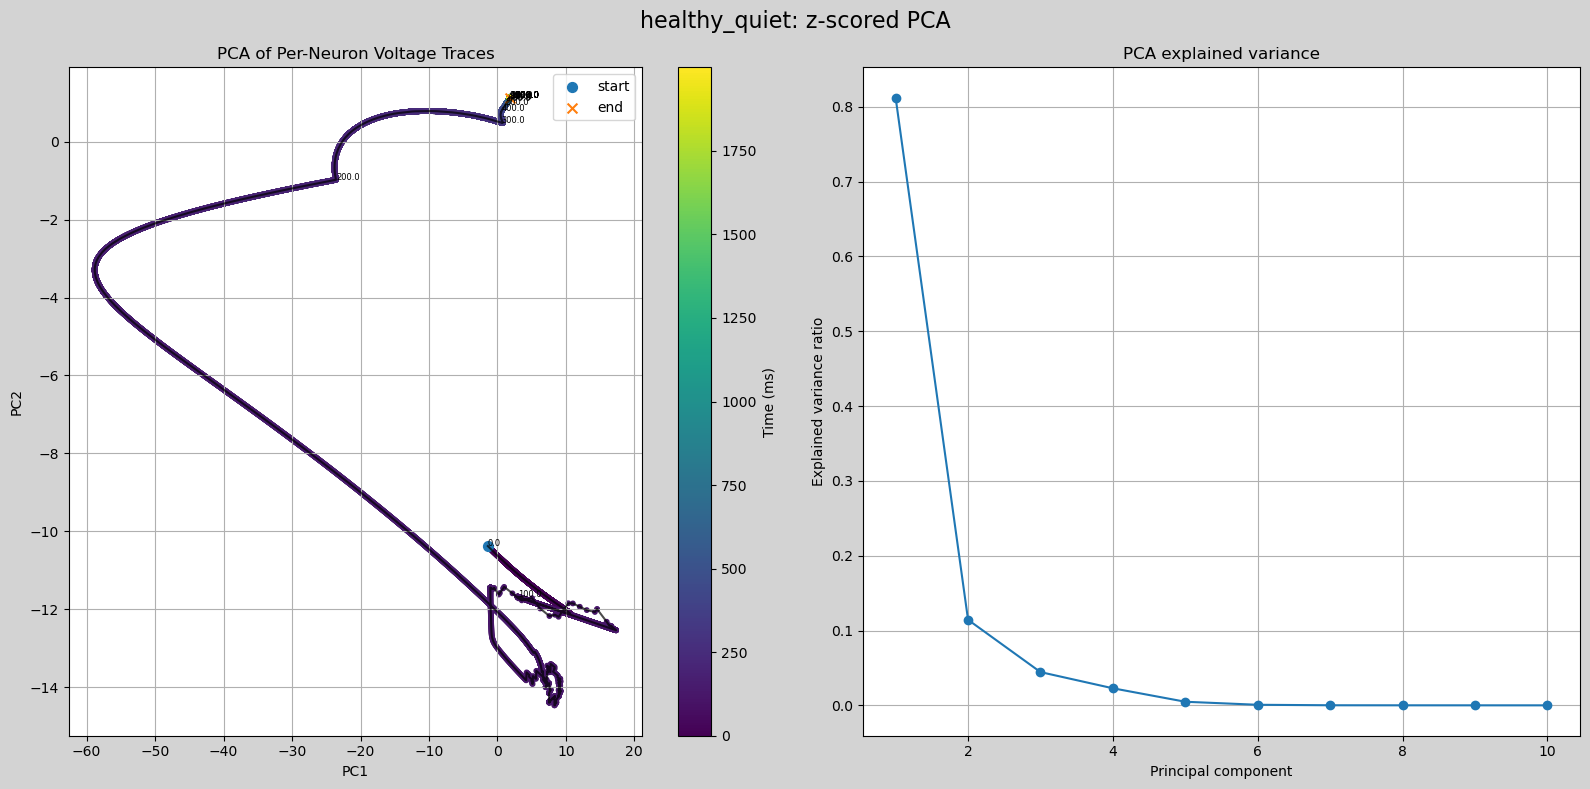


--- healthy_active_1 ---


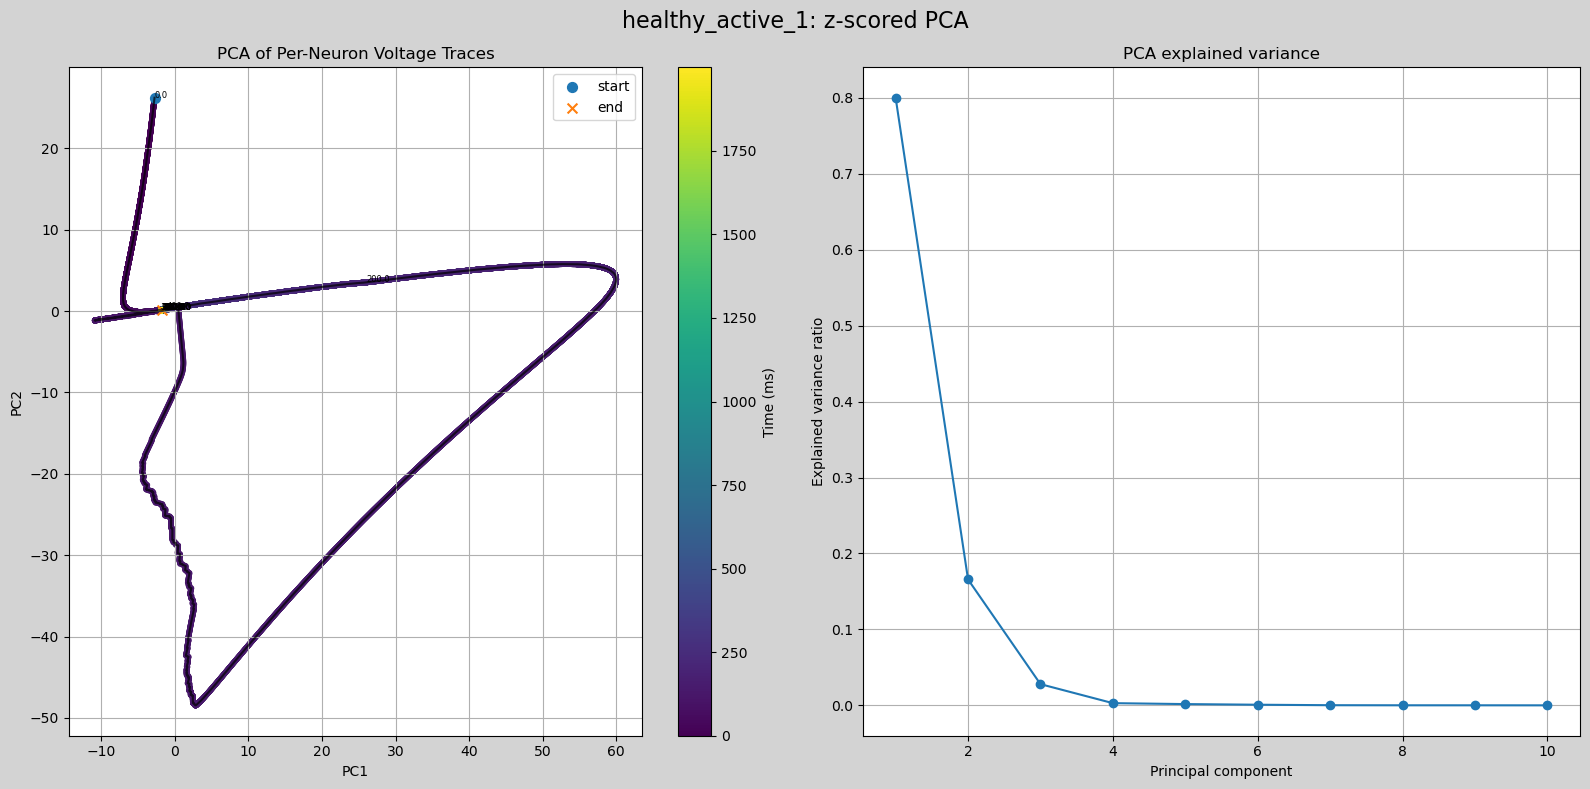


--- healthy_transition_1 ---


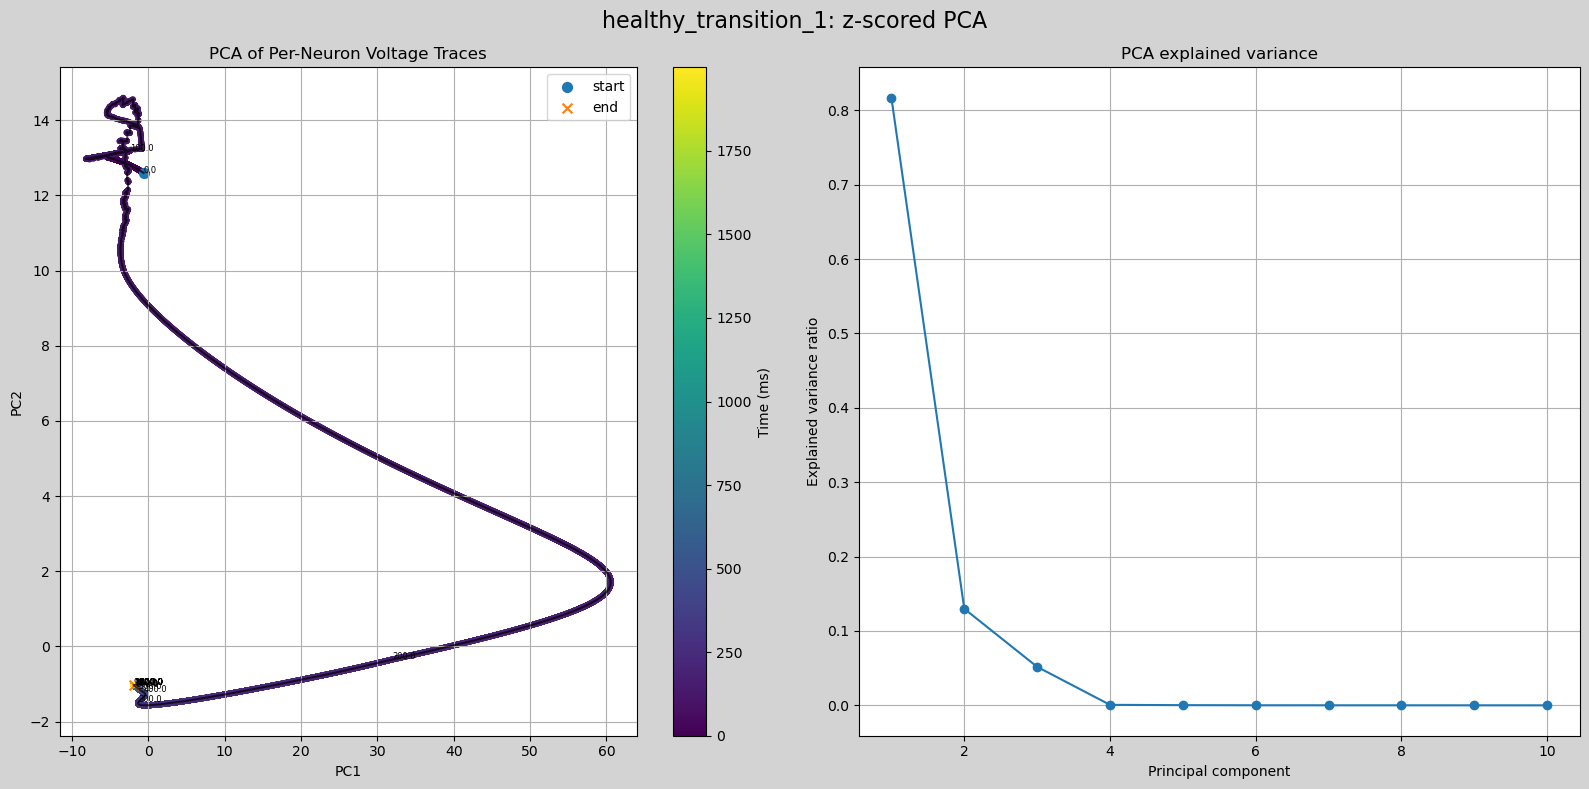


--- healthy_unstable_1 ---


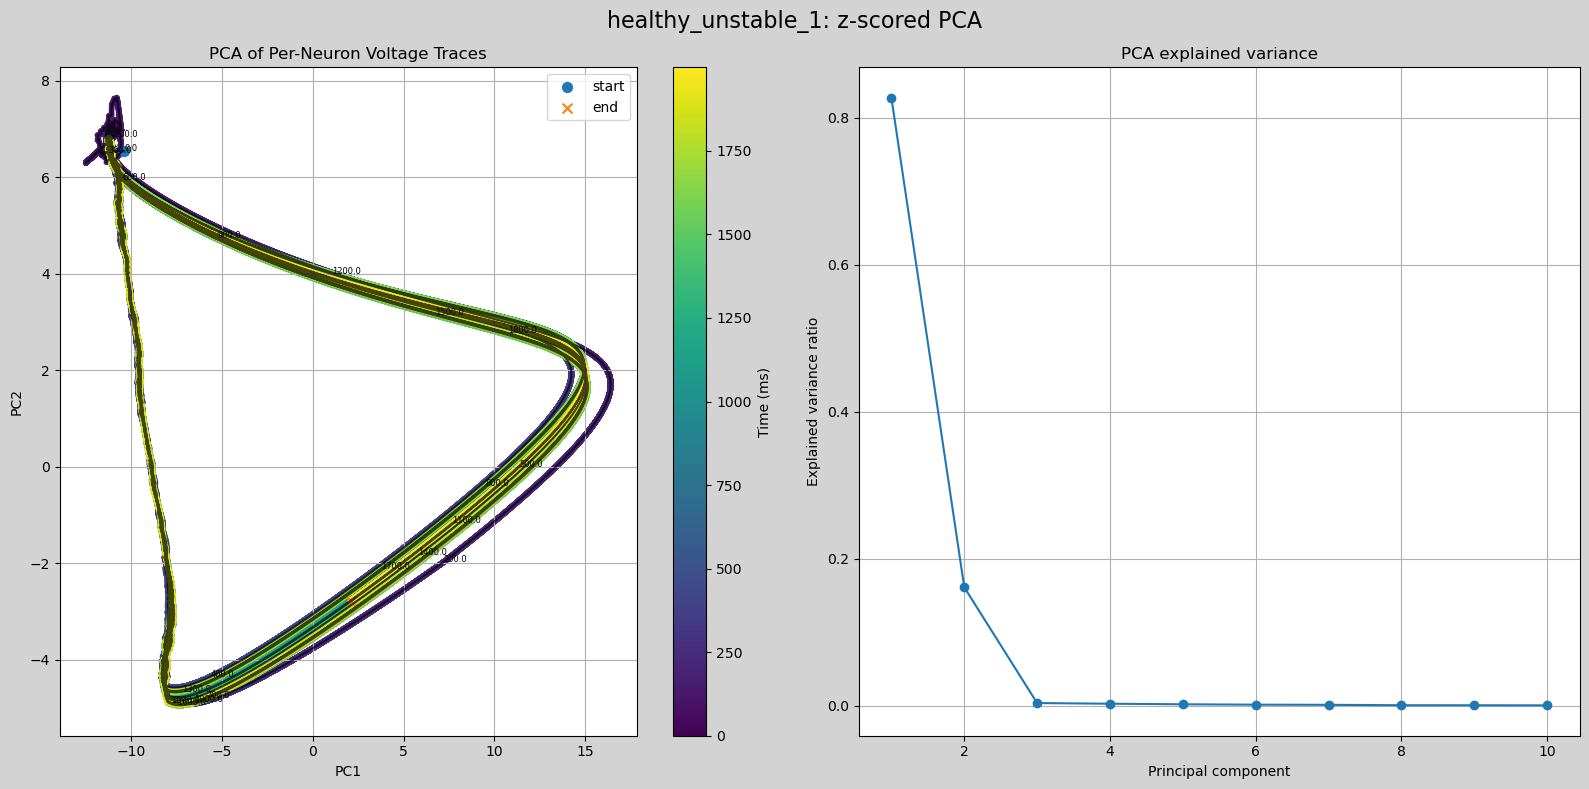

In [31]:
extnd_mode = False

save_plots = True

analysis_outputs = {}

for label, res in result_dict.items():
    print(f"\n--- {label} ---")

    # ---- Per neuron voltage traces ----
    v_df = pd.DataFrame(res.v_trace.T)
    v_df.columns = [f"v_neuron_{j}" for j in range(v_df.shape[1])]

    per_neuron_sim_results_df = pd.concat([
        pd.DataFrame({
        "t_ms": res.t_ms,
        "field_proxy": res.field_proxy,}),
        v_df,],axis=1,)

    # ---- Simulation metrics ----
    sim_metric_results = compute_metrics(res, save=False,)

    # ---- PCA on raw traces ----
    projected_df_raw, eigenvalues_raw, eigenvectors_raw, explained_variance_ratio_raw = calvo_pca(
        v_df,
        n_components=10,)

    if extnd_mode:
        print(projected_df_raw.head())
        print("Top 10 eigenvalues (raw):", eigenvalues_raw[:10])
        print("Top 10 explained variance ratios (raw):", explained_variance_ratio_raw[:10])

    # ---- Z-score standardized traces ----
    v_df_z = (v_df - v_df.mean()) / v_df.std(ddof=0)
    v_df_z = v_df_z.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

    # Z-scored PCA plot
    projected_df_z, eigenvalues_z, eigenvectors_z, explained_variance_ratio_z = calvo_pca(
        v_df_z, n_components=10,)

    # Z-scored PCA plot
    fig, projected_df_raw, eigenvalues_raw, eigenvectors_raw, explained_variance_ratio_raw = calvo_pca_plot(
        res, n_components=10, title=label,)
    if save_plots:
        fig.savefig(plt_save_path / f"{label}_pca_z_{cfg.simulation.duration_ms}.png")

    if extnd_mode:
        print(projected_df_z.head())
        print("Top 10 eigenvalues (z):", eigenvalues_z[:10])
        print("Top 10 explained variance ratios (z):", explained_variance_ratio_z[:10])

    analysis_outputs[label] = {
        "per_neuron_df": per_neuron_sim_results_df,
        "metrics": sim_metric_results,
        "pca_raw": {
            "projected_df": projected_df_raw,
            "eigenvalues": eigenvalues_raw,
            "eigenvectors": eigenvectors_raw,
            "explained_variance_ratio": explained_variance_ratio_raw,
        },
        "pca_z": {
            "projected_df": projected_df_z,
            "eigenvalues": eigenvalues_z,
            "eigenvectors": eigenvectors_z,
            "explained_variance_ratio": explained_variance_ratio_z,
        },
    }

In [ ]:
# Create a dictionary to store analysis results for easy access and comparison
analysis_dict = {}

# --- Run PCA analysis for each result and store in analysis_dict ---
for label in result_dict:
    print(f"--- Analyzing: {label} ---")
    analysis_dict[label] = pca_analysis(result_dict[label])

print("PCA analysis categories:", list(analysis_dict.keys()))


--- Analyzing: healthy_quiet ---
--- Analyzing: healthy_active_1 ---
--- Analyzing: healthy_transition_1 ---
--- Analyzing: healthy_unstable_1 ---


In [36]:
print("\nPCA analysis for all conditions:")
for label, analysis in analysis_dict.items():
    print(f"\n--- {label} ---")
    print("Projected DataFrame head:")
    print(analysis["projected_df"].head())
    print("Top 10 eigenvalues:", analysis["eigenvalues"][:10])
    print("Top 10 explained variance ratios:", analysis["explained_variance_ratio"][:10])



PCA analysis for all conditions:

--- healthy_quiet ---
Projected DataFrame head:
        PC1        PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.404128 -10.379645 -0.052056  7.894843 -1.007860  1.452729  0.670585   
1 -1.394730 -10.381332 -0.051373  7.888413 -1.006741  1.451050  0.669859   
2 -1.385391 -10.383054 -0.050703  7.881845 -1.005507  1.449485  0.669015   
3 -1.376149 -10.384723 -0.050030  7.875359 -1.004458  1.447930  0.668261   
4 -1.366843 -10.386340 -0.049326  7.869209 -1.003102  1.446481  0.667644   

        PC8       PC9      PC10  t_ms  
0 -0.245636  0.318156 -0.376304  0.00  
1 -0.245425  0.317846 -0.375818  0.01  
2 -0.245254  0.317629 -0.375521  0.02  
3 -0.244938  0.317442 -0.375105  0.03  
4 -0.244720  0.317092 -0.374743  0.04  
Top 10 eigenvalues: [8.12238532e+01 1.14384070e+01 4.44816257e+00 2.28282151e+00
 4.82905923e-01 7.84493688e-02 1.40377011e-02 7.33844787e-03
 5.15522721e-03 3.36906991e-03]
Top 10 explained variance ratios: [8.12234471e